# 08 - Ball + Made Basket Detection

In questo notebook viene sviluppata una baseline per il rilevamento automatico di:

- basketball
- made basket

su video di basket con inquadratura broadcast.

Il modello utilizzato è RF-DETR Nano.

## Pipeline

Basketball Broadcast Dataset
→ Dataset Audit
→ Bounding Box Analysis
→ Smoke Test
→ RF-DETR Fine-Tuning
→ Evaluation
→ Inference su video broadcast

Il rilevamento di `made basket` verrà successivamente integrato con
la detection del ferro e con la traiettoria temporale della palla
per il riconoscimento degli eventi di tiro.

In [37]:
from pathlib import Path

import json
import random
import shutil

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import supervision as sv

from PIL import Image

from rfdetr import RFDETRNano, RFDETR

In [38]:
DRIVE_ROOT = Path(
    "/Users/marcodalbis/Library/CloudStorage/"
    "GoogleDrive-marco.dalbis@gmail.com/"
    "Il mio Drive/"
    "basketball-thesis"
)

DATASETS_ROOT = (
    DRIVE_ROOT
    / "datasets"
)

RAW_DATASET_DIR = (
    DATASETS_ROOT
    / "Basketball Broadcast.v21-ball-and-made-basket-augmentation-2.coco"
)

MY_VIDEOS_DIR = (
    DRIVE_ROOT
    / "videos"
)

OUTPUT_DIR = (
    DRIVE_ROOT
    / "experiments"
    / "ball_made_detection"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "Drive:",
    DRIVE_ROOT.exists()
)

print(
    "Dataset:",
    RAW_DATASET_DIR.exists()
)

print(
    "My videos:",
    MY_VIDEOS_DIR.exists()
)

print(
    "Output:",
    OUTPUT_DIR
)

Drive: True
Dataset: True
My videos: True
Output: /Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/experiments/ball_made_detection


In [39]:
print("Cartelle presenti in datasets:\n")

for path in sorted(DATASETS_ROOT.iterdir()):
    if path.is_dir():
        print(repr(path.name))

Cartelle presenti in datasets:

'Basketball Broadcast.v21-ball-and-made-basket-augmentation-2.coco'
'Basketball and rim.v1i.coco'
'Basketball.ball_rim.coco'
'Basketball.v2i.coco'
'basketball.v1i.coco'
'sportsmot'
'sportsmot_coco'


In [40]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

RESOLUTION = 512

SPLITS = [
    "train",
    "valid",
    "test"
]

print(
    "Seed:",
    SEED
)

print(
    "Resolution:",
    RESOLUTION
)

Seed: 42
Resolution: 512


In [41]:
for split in SPLITS:

    split_dir = (
        RAW_DATASET_DIR
        / split
    )

    annotation_file = (
        split_dir
        / "_annotations.coco.json"
    )

    print(
        split
    )

    print(
        "  Folder:",
        split_dir.exists()
    )

    print(
        "  COCO JSON:",
        annotation_file.exists()
    )

train
  Folder: True
  COCO JSON: True
valid
  Folder: True
  COCO JSON: True
test
  Folder: True
  COCO JSON: True


In [42]:
def load_coco(
    split_dir
):

    annotation_file = (
        split_dir
        / "_annotations.coco.json"
    )

    with open(
        annotation_file,
        "r",
        encoding="utf-8"
    ) as f:

        coco = json.load(
            f
        )

    return coco

In [43]:
for split in SPLITS:

    coco = load_coco(
        RAW_DATASET_DIR
        / split
    )

    print(
        "\n" + "=" * 60
    )

    print(
        split.upper()
    )

    print(
        "=" * 60
    )

    print(
        "Images:",
        len(
            coco["images"]
        )
    )

    print(
        "Annotations:",
        len(
            coco["annotations"]
        )
    )

    print(
        "\nCategories:"
    )

    for category in coco[
        "categories"
    ]:

        print(
            category
        )


TRAIN
Images: 3249
Annotations: 3249

Categories:
{'id': 0, 'name': 'players-ball-court-hoop', 'supercategory': 'none'}
{'id': 1, 'name': 'Ball', 'supercategory': 'players-ball-court-hoop'}
{'id': 2, 'name': 'Made Basket', 'supercategory': 'players-ball-court-hoop'}

VALID
Images: 311
Annotations: 312

Categories:
{'id': 0, 'name': 'players-ball-court-hoop', 'supercategory': 'none'}
{'id': 1, 'name': 'Ball', 'supercategory': 'players-ball-court-hoop'}
{'id': 2, 'name': 'Made Basket', 'supercategory': 'players-ball-court-hoop'}

TEST
Images: 148
Annotations: 148

Categories:
{'id': 0, 'name': 'players-ball-court-hoop', 'supercategory': 'none'}
{'id': 1, 'name': 'Ball', 'supercategory': 'players-ball-court-hoop'}
{'id': 2, 'name': 'Made Basket', 'supercategory': 'players-ball-court-hoop'}


In [44]:
def get_class_distribution(
    coco
):

    category_map = {
        category["id"]:
        category["name"]

        for category
        in coco["categories"]
    }

    counts = {
        category_id: 0

        for category_id
        in category_map
    }

    for annotation in coco[
        "annotations"
    ]:

        category_id = (
            annotation[
                "category_id"
            ]
        )

        counts[
            category_id
        ] += 1

    rows = []

    for category_id, count in counts.items():

        rows.append({
            "category_id":
                category_id,

            "class_name":
                category_map[
                    category_id
                ],

            "annotations":
                count
        })

    return pd.DataFrame(
        rows
    )

In [45]:
for split in SPLITS:

    coco = load_coco(
        RAW_DATASET_DIR
        / split
    )

    print(
        "\n",
        split.upper()
    )

    display(
        get_class_distribution(
            coco
        )
    )


 TRAIN


,category_id,class_name,annotations
0,0,players-ball-court-hoop,0
1,1,Ball,2172
2,2,Made Basket,1077



 VALID


,category_id,class_name,annotations
0,0,players-ball-court-hoop,0
1,1,Ball,208
2,2,Made Basket,104



 TEST


,category_id,class_name,annotations
0,0,players-ball-court-hoop,0
1,1,Ball,101
2,2,Made Basket,47


Bounding Box Analysis

In [46]:
def build_bbox_dataframe(
    dataset_dir,
    split
):

    coco = load_coco(
        dataset_dir
        / split
    )

    images = {
        image["id"]:
        image

        for image
        in coco["images"]
    }

    categories = {
        category["id"]:
        category["name"]

        for category
        in coco["categories"]
    }

    rows = []

    for annotation in coco[
        "annotations"
    ]:

        image = images[
            annotation[
                "image_id"
            ]
        ]

        x, y, width, height = (
            annotation[
                "bbox"
            ]
        )

        bbox_area = (
            width
            * height
        )

        image_area = (
            image["width"]
            * image["height"]
        )

        rows.append({

            "split":
                split,

            "class_name":
                categories[
                    annotation[
                        "category_id"
                    ]
                ],

            "bbox_width":
                width,

            "bbox_height":
                height,

            "bbox_area":
                bbox_area,

            "relative_area":
                (
                    bbox_area
                    / image_area
                )
        })

    return pd.DataFrame(
        rows
    )

In [47]:
bbox_df = pd.concat(
    [
        build_bbox_dataframe(
            RAW_DATASET_DIR,
            split
        )

        for split
        in SPLITS
    ],

    ignore_index=True
)

print(
    "Bounding boxes:",
    len(
        bbox_df
    )
)

Bounding boxes: 3709


In [48]:
display(
    bbox_df.groupby(
        [
            "split",
            "class_name"
        ]
    )[
        [
            "bbox_width",
            "bbox_height",
            "relative_area"
        ]
    ].describe()
)

bbox_width                                                  \
                       count       mean        std   min   25%   50%     75%   
split class_name                                                               
test  Ball             101.0  16.133663  10.417987   5.5  10.0  12.0  16.500   
      Made Basket       47.0  44.978723  40.531517  16.0  21.5  26.5  45.000   
train Ball            2172.0  15.643646  10.541820   4.0   9.5  11.5  15.500   
      Made Basket     1077.0  47.422006  36.545637   9.0  22.0  29.5  70.500   
valid Ball             208.0  15.379808  10.054560   5.5   9.5  11.0  15.000   
      Made Basket      104.0  41.110577  29.922145  11.5  22.5  25.5  52.375   

                         bbox_height             ...                  \
                     max       count       mean  ...      75%    max   
split class_name                                 ...                   
test  Ball          56.0       101.0  29.173267  ...   30.500   97.0   
      Made Basket  187.0        47.0  81.393617  ...   80.750  297.5   
train Ball         113.5      2172.0  28.274862  ...   28.500  186.0   
      Made Basket  184.5      1077.0  87.642061  ...  131.500  351.0   
valid Ball          71.5       208.0  28.480769  ...   28.125  121.5   
      Made Basket  132.0       104.0  76.692308  ...   91.750  273.0   

                  relative_area                                          \
                          count      mean       std       min       25%   
split class_name                                                          
test  Ball                101.0  0.001613  0.002347  0.000114  0.000452   
      Made Basket          47.0  0.015462  0.027956  0.000918  0.002054   
train Ball               2172.0  0.001550  0.002865  0.000122  0.000417   
      Made Basket        1077.0  0.016036  0.024102  0.000297  0.002102   
valid Ball                208.0  0.001524  0.002446  0.000134  0.000417   
      Made Basket         104.0  0.011665  0.017429  0.000463  0.002099   

                                                 
                        50%       75%       max  
split class_name                                 
test  Ball         0.000656  0.001229  0.013262  
      Made Basket  0.003385  0.008726  0.123111  
train Ball         0.000562  0.001012  0.051541  
      Made Basket  0.003565  0.024067  0.119604  
valid Ball         0.000551  0.001037  0.021209  
      Made Basket  0.003096  0.011436  0.082339  

[6 rows x 24 columns]

In [49]:
for class_name in sorted(
    bbox_df[
        "class_name"
    ].unique()
):

    class_df = bbox_df[
        bbox_df[
            "class_name"
        ]
        == class_name
    ]

    print(
        "\n" + "=" * 60
    )

    print(
        class_name
    )

    print(
        "=" * 60
    )

    print(
        "Annotations:",
        len(
            class_df
        )
    )

    print(
        "Median width:",
        class_df[
            "bbox_width"
        ].median()
    )

    print(
        "Median height:",
        class_df[
            "bbox_height"
        ].median()
    )

    print(
        "Median relative area:",
        class_df[
            "relative_area"
        ].median()
    )

    print(
        "10th percentile relative area:",
        class_df[
            "relative_area"
        ].quantile(
            0.10
        )
    )


Ball
Annotations: 2481
Median width: 11.5
Median height: 20.5
Median relative area: 0.00056396484375
10th percentile relative area: 0.000318603515625

Made Basket
Annotations: 1228
Median width: 29.0
Median height: 56.0
Median relative area: 0.0034954833984375
10th percentile relative area: 0.00138671875


In [50]:
def show_random_annotations(
    dataset_dir,
    split="train",
    n=9
):

    split_dir = (
        dataset_dir
        / split
    )

    coco = load_coco(
        split_dir
    )

    image_map = {
        image["id"]:
        image

        for image
        in coco["images"]
    }

    category_map = {
        category["id"]:
        category["name"]

        for category
        in coco["categories"]
    }

    annotations_by_image = {}

    for annotation in coco[
        "annotations"
    ]:

        annotations_by_image.setdefault(
            annotation[
                "image_id"
            ],
            []
        ).append(
            annotation
        )

    image_ids = list(
        image_map.keys()
    )

    sample_ids = random.sample(
        image_ids,
        min(
            n,
            len(
                image_ids
            )
        )
    )

    rows = 3
    cols = 3

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(
            15,
            12
        )
    )

    axes = axes.flatten()

    for ax, image_id in zip(
        axes,
        sample_ids
    ):

        image_info = (
            image_map[
                image_id
            ]
        )

        image = Image.open(
            split_dir
            / image_info[
                "file_name"
            ]
        ).convert(
            "RGB"
        )

        ax.imshow(
            image
        )

        for annotation in (
            annotations_by_image.get(
                image_id,
                []
            )
        ):

            x, y, w, h = (
                annotation[
                    "bbox"
                ]
            )

            class_name = (
                category_map[
                    annotation[
                        "category_id"
                    ]
                ]
            )

            rectangle = (
                plt.Rectangle(
                    (
                        x,
                        y
                    ),
                    w,
                    h,
                    fill=False,
                    linewidth=2
                )
            )

            ax.add_patch(
                rectangle
            )

            ax.text(
                x,
                max(
                    0,
                    y - 4
                ),
                class_name,
                fontsize=7
            )

        ax.axis(
            "off"
        )

    plt.tight_layout()
    plt.show()

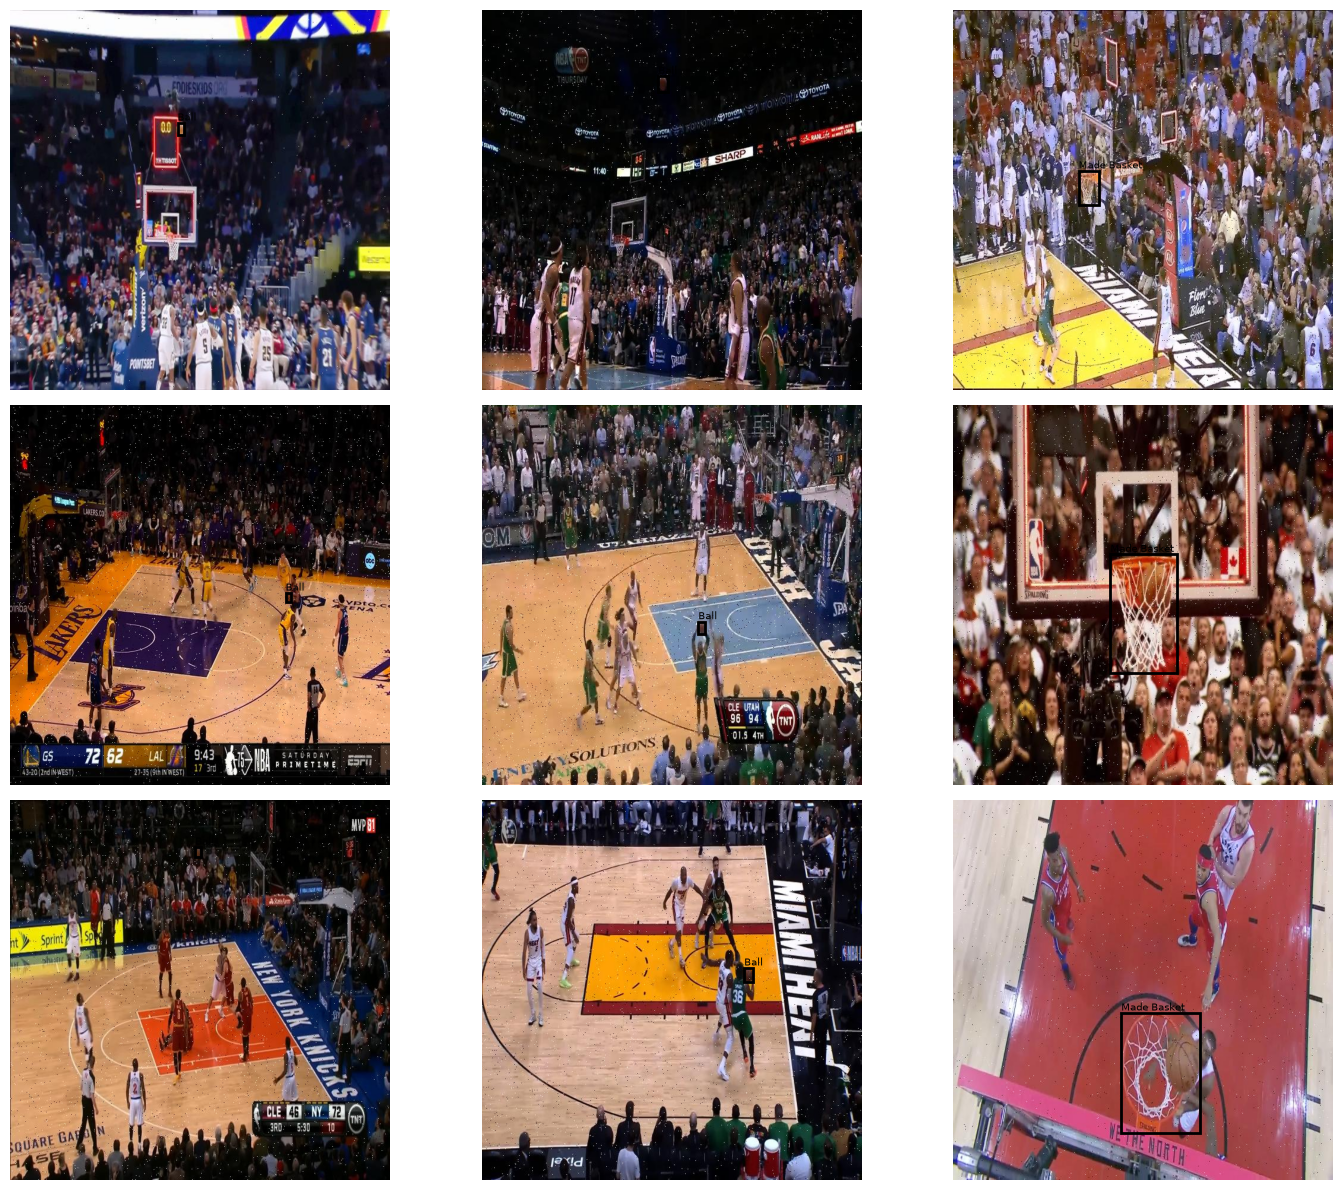

In [51]:
show_random_annotations(
    RAW_DATASET_DIR,
    split="train",
    n=9
)

Smoke Test

In [52]:
SMOKE_DATASET_DIR = (
    DATASETS_ROOT
    / "basketball_ball_made_smoke"
)

SMOKE_OUTPUT_DIR = (
    OUTPUT_DIR
    / "smoke"
)

SMOKE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

SMOKE_CHECKPOINT = (
    SMOKE_OUTPUT_DIR
    / "checkpoint_best_total.pth"
)

print(
    "Smoke dataset:",
    SMOKE_DATASET_DIR
)

print(
    "Smoke output:",
    SMOKE_OUTPUT_DIR
)

Smoke dataset: /Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/datasets/basketball_ball_made_smoke
Smoke output: /Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/experiments/ball_made_detection/smoke


In [53]:
def create_subset_split(
    source_dir,
    destination_dir,
    n_images
):

    destination_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    coco = load_coco(
        source_dir
    )

    images = (
        coco[
            "images"
        ].copy()
    )

    random.Random(
        SEED
    ).shuffle(
        images
    )

    selected_images = (
        images[
            :min(
                n_images,
                len(
                    images
                )
            )
        ]
    )

    selected_ids = {
        image["id"]

        for image
        in selected_images
    }

    annotations = [
        annotation

        for annotation
        in coco[
            "annotations"
        ]

        if annotation[
            "image_id"
        ]
        in selected_ids
    ]

    subset = {
        "info":
            coco.get(
                "info",
                {}
            ),

        "licenses":
            coco.get(
                "licenses",
                []
            ),

        "images":
            selected_images,

        "annotations":
            annotations,

        "categories":
            coco[
                "categories"
            ]
    }

    for image in selected_images:

        source_image = (
            source_dir
            / image[
                "file_name"
            ]
        )

        destination_image = (
            destination_dir
            / image[
                "file_name"
            ]
        )

        destination_image.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        shutil.copy2(
            source_image,
            destination_image
        )

    with open(
        destination_dir
        / "_annotations.coco.json",
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            subset,
            f,
            indent=2
        )

In [54]:
if SMOKE_DATASET_DIR.exists():

    print(
        "Smoke dataset già presente."
    )

else:

    create_subset_split(
        RAW_DATASET_DIR
        / "train",

        SMOKE_DATASET_DIR
        / "train",

        32
    )

    create_subset_split(
        RAW_DATASET_DIR
        / "valid",

        SMOKE_DATASET_DIR
        / "valid",

        16
    )

    create_subset_split(
        RAW_DATASET_DIR
        / "test",

        SMOKE_DATASET_DIR
        / "test",

        16
    )

    print(
        "Smoke dataset creato."
    )

Smoke dataset creato.


In [55]:
for split in [
    "train",
    "valid"
]:

    coco = load_coco(
        SMOKE_DATASET_DIR
        / split
    )

    print(
        "\n",
        split.upper()
    )

    display(
        get_class_distribution(
            coco
        )
    )


 TRAIN


,category_id,class_name,annotations
0,0,players-ball-court-hoop,0
1,1,Ball,21
2,2,Made Basket,11



 VALID


,category_id,class_name,annotations
0,0,players-ball-court-hoop,0
1,1,Ball,11
2,2,Made Basket,5


In [56]:
if SMOKE_CHECKPOINT.exists():

    print(
        "Smoke test già completato."
    )

    print(
        SMOKE_CHECKPOINT
    )

else:

    smoke_model = (
        RFDETRNano()
    )

    smoke_model.train(

        dataset_dir=str(
            SMOKE_DATASET_DIR
        ),

        epochs=1,

        batch_size=1,

        grad_accum_steps=1,

        lr=1e-4,

        resolution=RESOLUTION,

        device=DEVICE,

        output_dir=str(
            SMOKE_OUTPUT_DIR
        ),

        progress_bar="tqdm",

        compute_val_loss=True,

        checkpoint_interval=1,

        num_workers=0,

        seed=SEED
    )

[2026-10-07 15:34:05] [INFO] rf-detr - File /Users/marcodalbis/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


[2026-10-07 15:34:05] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-10-07 15:34:05] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-10-07 15:34:07] [INFO] rf-detr - File /Users/marcodalbis/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


[2026-10-07 15:34:11] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-10-07 15:34:11] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-10-07 15:34:13] [INFO] rf-detr - File /Users/marcodalbis/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Output()

[2026-10-07 15:36:32] [INFO] rf-detr - Best EMA metric improved to 0.0011 (epoch 0)


`Trainer.fit` stopped: `max_epochs=1` reached.


[2026-10-07 15:36:35] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.0000, ema=0.0011)


In [57]:
print(
    "Smoke checkpoint:",
    SMOKE_CHECKPOINT.exists()
)

print(
    "\nFiles:"
)

for file in sorted(
    SMOKE_OUTPUT_DIR.glob(
        "*"
    )
):

    print(
        file.name
    )

Smoke checkpoint: True

Files:
checkpoint_0.ckpt
checkpoint_best_ema.pth
checkpoint_best_total.pth
last_ema.pth
metrics.csv
training_config.json


Baseline 2 Epoche

In [58]:
BASELINE_OUTPUT_DIR = (
    OUTPUT_DIR
    / "baseline_2epochs"
)

BASELINE_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_CHECKPOINT = (
    BASELINE_OUTPUT_DIR
    / "checkpoint_best_total.pth"
)

print(
    BASELINE_OUTPUT_DIR
)

/Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/experiments/ball_made_detection/baseline_2epochs


In [ ]:
if BEST_CHECKPOINT.exists():

    print(
        "Training già completato."
    )

    print(
        "Checkpoint:"
    )

    print(
        BEST_CHECKPOINT
    )

else:

    model = (
        RFDETRNano()
    )

    model.train(

        dataset_dir=str(
            RAW_DATASET_DIR
        ),

        epochs=2,

        batch_size=1,

        grad_accum_steps=4,

        lr=1e-4,

        resolution=RESOLUTION,

        device=DEVICE,

        output_dir=str(
            BASELINE_OUTPUT_DIR
        ),

        progress_bar="tqdm",

        compute_val_loss=True,

        checkpoint_interval=1,

        num_workers=0,

        seed=SEED
    )

[2026-10-07 15:45:39] [INFO] rf-detr - File /Users/marcodalbis/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


[2026-10-07 15:45:39] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-10-07 15:45:39] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-10-07 15:45:41] [INFO] rf-detr - File /Users/marcodalbis/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


[2026-10-07 15:45:45] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-10-07 15:45:45] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-10-07 15:45:47] [INFO] rf-detr - File /Users/marcodalbis/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


...

/Users/marcodalbis/Desktop/Tesi Magistrale/basketball-thesis/basketball-thesis/.venv/lib/python3.11/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/marcodalbis/Library/CloudStorage/GoogleDrive-marco.dalbis@gmail.com/Il mio Drive/basketball-thesis/experiments/ball_made_detection/baseline_2epochs exists and is not empty.
Loading `train_dataloader` to estimate number of stepping batches.


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type         ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model       │ LWDETR       │ 30.3 M │ train │     0 │
│ 1 │ criterion   │ SetCriterion │      0 │ train │     0 │
│ 2 │ postprocess │ PostProcess  │      0 │ train │     0 │
└───┴─────────────┴──────────────┴────────┴───────┴───────┘

Trainable params: 30.3 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 30.3 M                                                                                               
Total estimated model params size (MB): 121.291                                                                    
Modules in train mode: 449                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Seed set to 42


Training: |          | 0/? [00:00<?, ?it/s]

In [ ]:
print(
    "Best checkpoint:",
    BEST_CHECKPOINT.exists()
)

print(
    "\nFiles:"
)

for file in sorted(
    BASELINE_OUTPUT_DIR.glob(
        "*"
    )
):

    print(
        file.name
    )

In [ ]:
assert BEST_CHECKPOINT.exists(), (
    "checkpoint_best_total.pth non trovato."
)

model = (
    RFDETR.from_checkpoint(
        str(
            BEST_CHECKPOINT
        )
    )
)

print(
    "Model loaded."
)

In [ ]:
test_metrics = (
    model.evaluate(

        dataset_dir=str(
            RAW_DATASET_DIR
        ),

        split="test",

        batch_size=1,

        resolution=RESOLUTION,

        device=DEVICE,

        num_workers=0
    )
)

print(
    "\nTEST METRICS"
)

print(
    "=" * 60
)

for key, value in (
    test_metrics.items()
):

    print(
        key,
        ":",
        value
    )

In [ ]:
METRICS_FILE = (
    BASELINE_OUTPUT_DIR
    / "test_metrics.json"
)

serializable_metrics = {}

for key, value in (
    test_metrics.items()
):

    try:

        serializable_metrics[
            key
        ] = float(
            value
        )

    except Exception:

        serializable_metrics[
            key
        ] = str(
            value
        )


with open(
    METRICS_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        serializable_metrics,
        f,
        indent=2
    )

print(
    "Saved:",
    METRICS_FILE
)

In [ ]:
box_annotator = (
    sv.BoxAnnotator(
        thickness=2
    )
)

label_annotator = (
    sv.LabelAnnotator()
)

Immagini test

In [ ]:
TEST_DIR = (
    RAW_DATASET_DIR
    / "test"
)

test_coco = load_coco(
    TEST_DIR
)

test_images = [
    TEST_DIR
    / image[
        "file_name"
    ]

    for image
    in test_coco[
        "images"
    ]
]

random.Random(
    SEED
).shuffle(
    test_images
)

sample_images = (
    test_images[:9]
)

print(
    "Test images:",
    len(
        test_images
    )
)

Prediction

In [ ]:
fig, axes = plt.subplots(
    3,
    3,
    figsize=(
        15,
        15
    )
)

for ax, image_path in zip(
    axes.flatten(),
    sample_images
):

    detections = (
        model.predict(
            str(
                image_path
            ),
            threshold=0.20
        )
    )

    image = np.array(
        Image.open(
            image_path
        ).convert(
            "RGB"
        )
    )

    class_names = (
        detections.data[
            "class_name"
        ]
    )

    labels = [
        f"{name} {confidence:.2f}"

        for name, confidence
        in zip(
            class_names,
            detections.confidence
        )
    ]

    annotated = (
        box_annotator.annotate(
            scene=image.copy(),
            detections=detections
        )
    )

    annotated = (
        label_annotator.annotate(
            scene=annotated,
            detections=detections,
            labels=labels
        )
    )

    ax.imshow(
        annotated
    )

    ax.set_title(
        image_path.name,
        fontsize=7
    )

    ax.axis(
        "off"
    )

plt.tight_layout()
plt.show()

Broadcast Test

In [ ]:
VIDEO_EXTENSIONS = {
    ".mp4",
    ".mov",
    ".avi",
    ".mkv"
}

video_paths = sorted(
    [
        path

        for path
        in MY_VIDEOS_DIR.iterdir()

        if path.suffix.lower()
        in VIDEO_EXTENSIONS
    ]
)

print(
    "Video trovati:",
    len(
        video_paths
    )
)

for path in video_paths:

    print(
        path.name
    )

In [ ]:
BROADCAST_OUTPUT_DIR = (
    OUTPUT_DIR
    / "broadcast_test"
)

FRAMES_OUTPUT_DIR = (
    BROADCAST_OUTPUT_DIR
    / "sample_frames"
)

PREDICTIONS_OUTPUT_DIR = (
    BROADCAST_OUTPUT_DIR
    / "frame_predictions"
)

VIDEO_OUTPUT_DIR = (
    BROADCAST_OUTPUT_DIR
    / "videos"
)

for directory in [
    FRAMES_OUTPUT_DIR,
    PREDICTIONS_OUTPUT_DIR,
    VIDEO_OUTPUT_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )

In [ ]:
FRAMES_PER_VIDEO = 8

for video_path in video_paths:

    cap = cv2.VideoCapture(
        str(
            video_path
        )
    )

    total_frames = int(
        cap.get(
            cv2.CAP_PROP_FRAME_COUNT
        )
    )

    frame_indices = np.linspace(
        0,
        total_frames - 1,
        FRAMES_PER_VIDEO,
        dtype=int
    )

    for frame_index in frame_indices:

        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            int(
                frame_index
            )
        )

        success, frame = (
            cap.read()
        )

        if not success:
            continue

        output_path = (
            FRAMES_OUTPUT_DIR
            / (
                f"{video_path.stem}"
                f"_frame_{frame_index:06d}.jpg"
            )
        )

        cv2.imwrite(
            str(
                output_path
            ),
            frame
        )

    cap.release()


broadcast_frames = sorted(
    FRAMES_OUTPUT_DIR.glob(
        "*.jpg"
    )
)

print(
    "Frames:",
    len(
        broadcast_frames
    )
)

In [ ]:
broadcast_results = []

for image_path in broadcast_frames:

    image_bgr = cv2.imread(
        str(
            image_path
        )
    )

    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )

    detections = (
        model.predict(
            image_rgb,
            threshold=0.15
        )
    )

    class_names = (
        detections.data[
            "class_name"
        ]
    )

    labels = [
        f"{name} {confidence:.2f}"

        for name, confidence
        in zip(
            class_names,
            detections.confidence
        )
    ]

    annotated = (
        box_annotator.annotate(
            scene=image_rgb.copy(),
            detections=detections
        )
    )

    annotated = (
        label_annotator.annotate(
            scene=annotated,
            detections=detections,
            labels=labels
        )
    )

    output_path = (
        PREDICTIONS_OUTPUT_DIR
        / image_path.name
    )

    Image.fromarray(
        annotated
    ).save(
        output_path
    )

    for class_name, confidence in zip(
        class_names,
        detections.confidence
    ):

        broadcast_results.append({
            "image":
                image_path.name,

            "class_name":
                str(
                    class_name
                ),

            "confidence":
                float(
                    confidence
                )
        })

In [ ]:
broadcast_df = pd.DataFrame(
    broadcast_results
)

display(
    broadcast_df
)

if not broadcast_df.empty:

    summary = (
        broadcast_df.groupby(
            "class_name"
        ).agg(
            detections=(
                "class_name",
                "count"
            ),

            mean_confidence=(
                "confidence",
                "mean"
            ),

            max_confidence=(
                "confidence",
                "max"
            )
        )
    )

    display(
        summary
    )

In [ ]:
prediction_paths = sorted(
    PREDICTIONS_OUTPUT_DIR.glob(
        "*.jpg"
    )
)

sample_predictions = (
    prediction_paths[:12]
)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(
        20,
        12
    )
)

for ax, image_path in zip(
    axes.flatten(),
    sample_predictions
):

    image = Image.open(
        image_path
    ).convert(
        "RGB"
    )

    ax.imshow(
        image
    )

    ax.set_title(
        image_path.name,
        fontsize=7
    )

    ax.axis(
        "off"
    )

plt.tight_layout()
plt.show()

Funzione completa

In [ ]:
def process_video(
    video_path,
    model,
    output_dir,
    threshold=0.15
):

    cap = cv2.VideoCapture(
        str(
            video_path
        )
    )

    fps = cap.get(
        cv2.CAP_PROP_FPS
    )

    width = int(
        cap.get(
            cv2.CAP_PROP_FRAME_WIDTH
        )
    )

    height = int(
        cap.get(
            cv2.CAP_PROP_FRAME_HEIGHT
        )
    )

    total_frames = int(
        cap.get(
            cv2.CAP_PROP_FRAME_COUNT
        )
    )

    output_video = (
        output_dir
        / (
            f"{video_path.stem}"
            "_ball_made.mp4"
        )
    )

    output_csv = (
        output_dir
        / (
            f"{video_path.stem}"
            "_ball_made.csv"
        )
    )

    writer = cv2.VideoWriter(
        str(
            output_video
        ),

        cv2.VideoWriter_fourcc(
            *"mp4v"
        ),

        fps,

        (
            width,
            height
        )
    )

    rows = []

    frame_id = 0

    while True:

        success, frame_bgr = (
            cap.read()
        )

        if not success:
            break

        frame_rgb = cv2.cvtColor(
            frame_bgr,
            cv2.COLOR_BGR2RGB
        )

        detections = (
            model.predict(
                frame_rgb,
                threshold=threshold
            )
        )

        class_names = (
            detections.data[
                "class_name"
            ]
        )

        labels = [
            f"{name} {confidence:.2f}"

            for name, confidence
            in zip(
                class_names,
                detections.confidence
            )
        ]

        annotated = (
            box_annotator.annotate(
                scene=frame_rgb.copy(),
                detections=detections
            )
        )

        annotated = (
            label_annotator.annotate(
                scene=annotated,
                detections=detections,
                labels=labels
            )
        )

        for (
            bbox,
            confidence,
            class_name
        ) in zip(
            detections.xyxy,
            detections.confidence,
            class_names
        ):

            x1, y1, x2, y2 = map(
                float,
                bbox
            )

            rows.append({

                "frame":
                    frame_id,

                "time_seconds":
                    frame_id
                    / fps,

                "class_name":
                    str(
                        class_name
                    ),

                "confidence":
                    float(
                        confidence
                    ),

                "x1":
                    x1,

                "y1":
                    y1,

                "x2":
                    x2,

                "y2":
                    y2,

                "center_x":
                    (
                        x1
                        + x2
                    )
                    / 2,

                "center_y":
                    (
                        y1
                        + y2
                    )
                    / 2
            })

        annotated_bgr = cv2.cvtColor(
            annotated,
            cv2.COLOR_RGB2BGR
        )

        writer.write(
            annotated_bgr
        )

        frame_id += 1

        if frame_id % 100 == 0:

            print(
                video_path.name,
                frame_id,
                "/",
                total_frames
            )

    cap.release()

    writer.release()

    result_df = pd.DataFrame(
        rows
    )

    result_df.to_csv(
        output_csv,
        index=False
    )

    return (
        output_video,
        output_csv,
        result_df
    )

In [ ]:
video_results = {}

for video_path in video_paths:

    print(
        "\nProcessing:",
        video_path.name
    )

    output_video, output_csv, detections_df = (
        process_video(

            video_path=video_path,

            model=model,

            output_dir=VIDEO_OUTPUT_DIR,

            threshold=0.15
        )
    )

    video_results[
        video_path.name
    ] = detections_df

    print(
        "Detections:",
        len(
            detections_df
        )
    )

    print(
        "Video:",
        output_video
    )

    print(
        "CSV:",
        output_csv
    )

In [ ]:
for video_name, detections_df in (
    video_results.items()
):

    print(
        "\n" + "=" * 60
    )

    print(
        video_name
    )

    print(
        "=" * 60
    )

    if detections_df.empty:

        print(
            "No detections"
        )

        continue

    display(
        detections_df.groupby(
            "class_name"
        ).agg(
            detections=(
                "class_name",
                "count"
            ),

            mean_confidence=(
                "confidence",
                "mean"
            ),

            max_confidence=(
                "confidence",
                "max"
            )
        )
    )